# Práctica: Predicción de Salarios con Random Forest

## Contexto

En el laboratorio anterior utilizamos **OLS, Lasso, Ridge y Elastic Net** sobre los datos CPS para predecir el logaritmo del salario por hora (`lwage`). Los métodos penalizados mejoraron la predicción al explotar un espacio de 246 interacciones.

Ahora incorporamos cuatro nuevos métodos:

- Regression Tree
- Random Forest
- Gradient Boosting
- XGBoost
---

## 1. Importaciones y configuración

In [1]:
import numpy as np
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import patsy
import warnings
warnings.simplefilter('ignore')

from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
import xgboost as xgb

sns.set_theme(style='whitegrid', palette='muted')
np.random.seed(22052026)

## Algo que se me olvidó mencionar en clase

Existe dos tipos de clasificaciones para los árboles de decisiones, los Decision Tree Classifier y los Decision Tree Regressor.
Los primeros sirven para variables dicotómicas, como la pregunta de breast_cancer es si tiene o no cancer, utilizamos Classifier. En este caso al tratar de predecir una variable continua (lwage), utilizamos Regressor.

---
## 2. Carga de datos y splits

Usamos exactamente el mismo split que en el laboratorio anterior random_state=42(es como el set.seed) para que los resultados sean comparables.

In [2]:
# ── Datos ──────────────────────────────────────────────────────────────────────
df = pl.read_csv('salarios.csv')
df_pd = df.to_pandas()
y = df_pd['lwage'].values

print(f'Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas')

# ── Matrices de diseño (mismas que en la práctica anterior) ────────────────────
# Modelo básico — 54 variables
X_basic = patsy.dmatrix(
    '0 + sex + exp1 + exp2 + exp3 + exp4 + shs + hsg + scl + clg + C(occ2) + C(ind2) + mw + so + we',
    df_pd, return_type='dataframe'
)
feat_basic = X_basic.columns.tolist()
X_basic = X_basic.values

# Modelo con interacciones — 246 variables
X_inter = patsy.dmatrix(
    '0 + sex + (exp1+exp2+exp3+exp4)*(shs+hsg+scl+clg+C(occ2)+C(ind2)+mw+so+we)',
    df_pd, return_type='dataframe'
)
feat_inter = X_inter.columns.tolist()
X_inter = X_inter.values

print(f'X básica:           {X_basic.shape[1]} variables')
print(f'X con interacciones: {X_inter.shape[1]} variables')

Dimensiones: 5150 filas × 20 columnas
X básica:           54 variables
X con interacciones: 246 variables


In [3]:
# ── Split train/test (mismo random_state que el laboratorio anterior) ──────────
idx_train, idx_test = train_test_split(
    np.arange(len(y)), test_size=0.2, random_state=42
)

X_b_train, X_b_test = X_basic[idx_train], X_basic[idx_test]
X_i_train, X_i_test = X_inter[idx_train], X_inter[idx_test]
y_train, y_test     = y[idx_train], y[idx_test]

print(f'Train: {len(y_train)} obs | Test: {len(y_test)} obs')

Train: 4120 obs | Test: 1030 obs


---
## 3. Benchmarks: OLS y Lasso

Reentrenamos los benchmarks del laboratorio anterior para tenerlos en la misma tabla comparativa.

In [4]:
# ── OLS básico ─────────────────────────────────────────────────────────────────
ols = LinearRegression().fit(X_b_train, y_train)
r2_ols = r2_score(y_test, ols.predict(X_b_test))

# ── Lasso con interacciones ────────────────────────────────────────────────────
lasso = LassoCV(cv=5, random_state=42, max_iter=5000).fit(X_i_train, y_train)
r2_lasso = r2_score(y_test, lasso.predict(X_i_test))

# ── Ridge con interacciones ────────────────────────────────────────────────────
ridge = RidgeCV(cv=5).fit(X_i_train, y_train)
r2_ridge = r2_score(y_test, ridge.predict(X_i_test))

print(f'OLS básico: R^2={r2_ols:.4f}')
print(f'Lasso (con interacciones): R^2={r2_lasso:.4f}')
print(f'Ridge (con interacciones): R^2={r2_ridge:.4f}')

OLS básico: R^2=0.2850
Lasso (con interacciones): R^2=0.2734
Ridge (con interacciones): R^2=0.2678


---
## 4. Árboles de la barranca

A diferencia de Lasso y Ridge, los árboles no requieren que especifiquemos las interacciones manualmente: las descubren ellos solos al partir el espacio. Por eso los ajustamos sobre `X_basic` (las 54 variables originales) el árbol encontrará los splits que capturan no linealidades e interacciones relevantes.

Por eso en este caso, no necesitamos crear una matriz nueva con patsy

### Ejercicio. Haz un arbolito


1. Crea un árbol de decisión de profundidad máxima 2, usa random_state=42 para reproducibilidad
2. Usa plot_tree para graficarlo, ponle colorcitos, fuente que te guste, título, ponlo chulo.

In [25]:
# ── TU CÓDIGO AQUÍ ────────────────────────────────────────────────────────────



# ──────────────────────────────────────────────────────────────────────────────

### Selección de profundidad óptima por validación cruzada

Esto es algo que expliqué pero no mostré el código, necesitas de alguna manera determinar la profundidad máxima del árbol, puedes usar varias medidas como el MSE, aunque en este caso vamos a usar la $R^2$.

In [5]:
rangos_profundida = range(1, 20)
lista_cv_profundiad = []

for d in rangos_profundida:
    tree_d = DecisionTreeRegressor(max_depth=d, random_state=42)
    lista_cv_profundiad.append(
        cross_val_score(tree_d, X_b_train, y_train, cv=5, scoring='r2').mean()
    )
    
df_cv = pd.DataFrame({
    'profundidad': list(rangos_profundida),
    'r2_cv_mean': lista_cv_profundiad
})

print(df_cv)

    profundidad  r2_cv_mean
0             1    0.059388
1             2    0.119051
2             3    0.148559
3             4    0.151260
4             5    0.156955
5             6    0.168207
6             7    0.167169
7             8    0.150730
8             9    0.110053
9            10    0.110928
10           11    0.077722
11           12    0.049366
12           13    0.004650
13           14   -0.039168
14           15   -0.068343
15           16   -0.085619
16           17   -0.118522
17           18   -0.159856
18           19   -0.185828


### Ejercicio

1. Grafica la profundidad de los arboles en el eje x y su $R^2$ en el eje Y.
2. Elige la profundidad óptima usando np.max

In [ ]:
# ── TU CÓDIGO AQUÍ ────────────────────────────────────────────────────────────



# ──────────────────────────────────────────────────────────────────────────────

---
## 5. Random Forest

### Ejercicio
1. Crea un random forest usando RandomForestRegressor, por ahora eres libre de elegir los parámetros, solo elige random_state=42 para reproducibilidad, revisa como va cambiando cuando usas diferentes parámetros como n_estimators, min_samples_leaf
Puedes ver la documentación del código aquí
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html
2. Haz el fit sobre X_b_train, y_train e imprime el $R^2$ y el oob_score

In [38]:
# ── TU CÓDIGO AQUÍ ────────────────────────────────────────────────────────────



# ──────────────────────────────────────────────────────────────────────────────

### Grafica las variables más importantes

In [6]:
## importances = Aca pon tu arbol del código anterior
feat_imp_df = pd.DataFrame({'feature': feat_basic, 'importance': importances})
feat_imp_df = feat_imp_df.sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=feat_imp_df, x='importance', y='feature',
            orient='h', ax=ax, palette='viridis')
ax.set_xlabel('Importancia')
ax.set_title('Top 15 variables')
plt.tight_layout()
plt.show()

NameError: name 'importances' is not defined

---
## Gradient Boosting

El gradient boosting construye los árboles de forma secuencial. Usamos early stopping implícito seleccionando `n_estimators` por la curva de convergencia en test. Normalmente usaríamos un conjunto de validación separado del test, aquí lo simplificamos para fines pedagógicos.

### Ejercicio
1. Crea un Gradient Boosting usando GradientBoostingRegressor, por ahora eres libre de elegir los parámetros, solo elige random_state=42 para reproducibilidad, revisa como va cambiando cuando usas diferentes parámetros como learning_rate, max_depth
Puedes ver la documentación del código aquí
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html
2. Haz el fit sobre X_b_train, y_train

In [ ]:
# ── TU CÓDIGO AQUÍ ────────────────────────────────────────────────────────────



# ──────────────────────────────────────────────────────────────────────────────

In [7]:
## Modifica este código para que funcione en tu arbol

r2_staged = [r2_score(y_test, yhat) for yhat in ##tu_arbol.staged_predict(X_b_test)]
best_J = np.argmax(r2_staged) + 1
r2_gb = max(r2_staged)

df_staged = pd.DataFrame({
    'N': range(1, len(r2_staged) + 1),
    'r2': r2_staged
})

df_staged

SyntaxError: '[' was never closed (236541776.py, line 3)

### Grafica el número de arboles vs $R^2$

Pon una linea vertical en el mejor J y una horizontal en el $R^2$ del estimador lasso

In [ ]:
# ── TU CÓDIGO AQUÍ ────────────────────────────────────────────────────────────



# ──────────────────────────────────────────────────────────────────────────────

---
## 7. XGBoost con Early Stopping
1. Crea un XGBoost usando xgb.XGBRegressor, por ahora eres libre de elegir los parámetros, solo elige random_state=42 y early_stopping_rounds=30 para reproducibilidad, revisa como va cambiando cuando usas diferentes parámetros como reg_lambda, n_estimators, reg_alpha
Puedes ver la documentación del código aquí
https://xgboost.readthedocs.io/en/latest/python/python_api.html#xgboost.XGBRFRegressor
2. Haz el fit sobre X_b_train, y_train

In [8]:
xgb_model = xgb.XGBRegressor(
    # Tus parametros
)

xgb_model.fit(
    X_b_train, y_train,
    eval_set=[(X_b_test, y_test)],
    verbose=False
)

r2_xgb = r2_score(y_test, xgb_model.predict(X_b_test))

print(f'Árboles usados (early stopping): {xgb_model.best_iteration}')
print(f'R2 test: {r2_xgb:.4f}')

AttributeError: `best_iteration` is only defined when early stopping is used.

---
## Compara todos los modelos por su $R^2$ puedes hacer un sucio data frame o si te quieres ver profesional una tabla bonita como great_tables

https://posit-dev.github.io/great-tables/articles/intro.html

In [ ]:
# ── TU CÓDIGO AQUÍ ────────────────────────────────────────────────────────────



# ──────────────────────────────────────────────────────────────────────────────

## Grafica las comparaciones

In [ ]:
# ── TU CÓDIGO AQUÍ ────────────────────────────────────────────────────────────



# ──────────────────────────────────────────────────────────────────────────────


## Análisis del mejor modelo: predicho vs. real. Crea un panel de gráficos donde veas el predicho vs el real de cada modelo.

In [ ]:
# ── TU CÓDIGO AQUÍ ────────────────────────────────────────────────────────────



# ──────────────────────────────────────────────────────────────────────────────

---
## La brecha salarial por sexo: ¿qué cambia con métodos no lineales?

En el laboratorio anterior estimamos la brecha salarial con OLS. Ahora podemos explorar si los métodos de árbol capturan heterogeneidad en esa brecha.

Una forma simple es predecir el salario para cada individuo con y sin `sex=1`, y calculamos la diferencia promedio

In [9]:
# Efecto marginal
# Usamos todo el conjunto de test como contrafactual
X_test_hombre = X_b_test.copy()
X_test_mujer  = X_b_test.copy()

idx_sex = feat_basic.index('sex') 
X_test_hombre[:, idx_sex] = 0
X_test_mujer[:, idx_sex]  = 1

modelos_gap = {
    'OLS':tu,
    'Random Forest':Tu_modelo,
    'Gradient Boosting':tu_modelo,
    'XGBoost':tu_modelo,
}

for name, model in modelos_gap.items():
    gap = model.predict(X_test_mujer) - model.predict(X_test_hombre)
    print(f'  {name:<25}  promedio = {gap.mean():.4f}  std = {gap.std():.4f}')

NameError: name 'rf' is not defined

NameError: name 'rf' is not defined

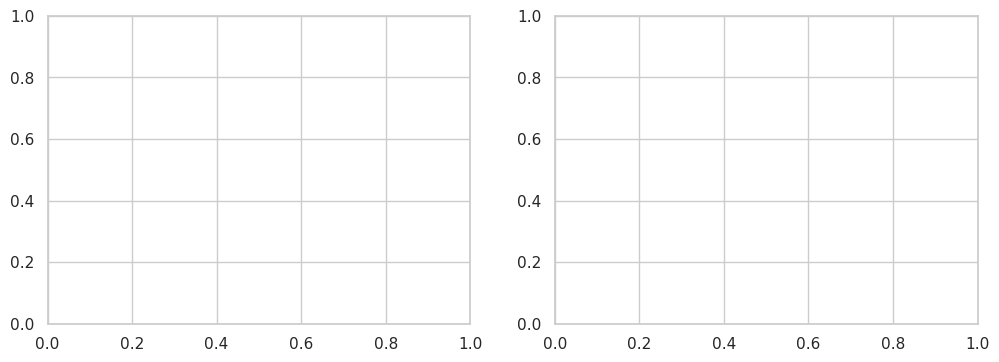

In [10]:
#Distribución 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, model) in zip(axes, {
    'Random Forest': tu_modelo,
    'XGBoost': tu_modelo
}.items()):
    gap = model.predict(X_test_mujer) - model.predict(X_test_hombre)
    sns.histplot(gap, bins=40, ax=ax, color='steelblue', kde=True)
    ax.axvline(gap.mean(), color='tomato', linestyle='--',
               label=f'Media = {gap.mean():.3f}')
    ax.set_xlabel('Brecha estimada')
    ax.set_title(f'Heterogeneidad de la brecha {name}')
    ax.legend()

fig.suptitle('Distribución de la brecha salarial por sexo según el modelo', fontsize=11)
plt.tight_layout()
plt.show()

---
##  ¿Por qué los métodos de árbol no necesitan las interacciones de Lasso?

Lasso y Ridge son lineales: para capturar que el efecto de la experiencia sobre el salario es diferente para personas con y sin universidad, necesitamos construir explícitamente el término `exp1 × clg`. De ahí las 246 columnas.

Los árboles de regresión son robustas a esas interacciones: al hacer el split `exp1 < 14` en el nodo de la izquierda (donde `clg < 0.5`) y `exp1 < 9.5` en el nodo de la derecha (donde `clg ≥ 0.5`), el árbol está implícitamente modelando la interacción `exp × clg` sin que se la especifiquemos.

###  Recuerden que esto no es causal

Los métodos de árbol son herramientas de predicción, no de inferencia causal. La diferencia en las predicciones de `sex=0` vs. `sex=1` **no es el efecto causal** del sexo sobre el salario.